# Machine Learning for Blood Transcriptomic Biomarkers of Parkinson’s Disease

## Dataset
**GEO accession:** GSE99039  
**Title:** *A blood-based gene signature characterizing Idiopathic Parkinson's disease*

## Project Goal
The goal of this project is to evaluate whether blood transcriptomic profiles can be used to distinguish patients with idiopathic Parkinson’s disease (PD) from healthy controls using machine learning methods.

## Research Question
Can gene expression data from peripheral blood be used to build an interpretable predictive model for Parkinson’s disease classification?

## Objectives
- Load and preprocess the GSE99039 expression dataset
- Select the relevant cohort: idiopathic PD vs healthy controls
- Perform exploratory data analysis
- Train baseline machine learning models
- Evaluate model performance
- Identify the most informative transcriptomic biomarkers

## Motivation
Reliable blood-based biomarkers for Parkinson’s disease may support earlier diagnosis and improve understanding of systemic molecular signatures associated with neurodegeneration.

## Workflow
1. Load GEO expression data  
2. Extract sample labels and build the analysis cohort  
3. Explore class balance and data structure  
4. Train baseline models  
5. Evaluate predictive performance  
6. Interpret model coefficients / feature importance  

## Notes
This notebook is intended as the main analysis notebook for the first stage of the project.

## Data Loading

We load the GEO Series Matrix file and extract the gene expression matrix.

In [1]:
#Импорты
import pandas as pd

file_path = "GSE99039_series_matrix.txt"

# пропускаем строки с metadata
data = pd.read_csv(file_path, sep="\t", comment="!")

In [2]:
data.head()

,ID_REF,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,...,GSM2631306,GSM2631307,GSM2631308,GSM2631309,GSM2631310,GSM2631311,GSM2631312,GSM2631313,GSM2631314,GSM2631315
0,1007_s_at,5.397,4.952,5.331,5.601,5.087,5.921,5.153,5.341,5.261,...,5.583,5.535,5.737,4.937,5.765,6.056,5.989,5.697,5.567,5.529
1,1053_at,5.199,5.198,4.970,5.816,5.443,5.430,5.243,5.167,5.324,...,5.775,5.004,5.672,5.415,5.195,5.282,5.228,5.528,5.706,5.078
2,117_at,8.327,8.589,8.629,9.628,9.449,9.230,9.269,9.095,9.184,...,8.426,7.061,6.771,8.691,7.073,7.325,8.567,6.844,8.511,8.458
3,121_at,7.042,6.935,7.701,6.909,7.284,7.153,6.850,7.541,6.918,...,7.192,7.326,7.319,6.702,7.747,7.712,7.743,7.468,7.526,7.673
4,1255_g_at,2.463,2.388,2.349,2.268,2.407,2.137,2.029,2.464,2.607,...,2.178,2.300,2.302,2.559,2.513,2.437,2.530,2.506,2.708,2.810


## Data Preparation

We convert the dataset into a machine learning–ready format.

* Rows correspond to samples (patients)
* Columns correspond to gene expression values

We extract sample labels from the metadata and define a binary classification task:

* CONTROL → 0 (healthy individuals)
* IPD → 1 (idiopathic Parkinson’s disease)

Samples corresponding to other neurological conditions (e.g., MSA, PSP, etc.) are excluded to ensure a clean binary classification setup.

This results in a filtered dataset containing only PD patients and healthy controls.

In [3]:
data = data.set_index("ID_REF")

# транспонируем → samples × genes
X = data.T
print(X.shape)         # должно быть (558, число_генов)

(558, 54675)


In [4]:
X.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM2630758,5.397,5.199,8.327,7.042,2.463,7.753,5.118,3.170,11.152,2.564,...,12.706,12.125,13.729,13.794,9.599,6.867,7.662,2.247,2.483,2.512
GSM2630759,4.952,5.198,8.589,6.935,2.388,8.210,5.107,2.677,11.029,2.603,...,11.955,11.334,13.432,13.374,9.313,5.786,7.116,2.155,2.445,2.331
GSM2630760,5.331,4.970,8.629,7.701,2.349,7.744,5.523,3.072,11.159,2.664,...,11.721,11.272,13.402,13.307,10.025,7.621,8.669,2.047,2.448,2.619
GSM2630761,5.601,5.816,9.628,6.909,2.268,7.670,4.579,3.025,10.528,2.551,...,11.549,10.737,13.180,13.179,8.817,6.220,7.168,2.055,2.356,2.409
GSM2630762,5.087,5.443,9.449,7.284,2.407,8.157,4.603,2.861,11.393,2.629,...,12.342,11.479,13.547,13.561,9.319,6.540,7.620,2.071,2.409,2.207


In [5]:
line = '"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: DRD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CBD"	"disease label: MSA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: Vascular dementia"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: PSP"	"disease label: GPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: MSA"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: MSA"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: PSP"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: DRD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: PSP"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: PSP"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: MSA"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: HD"	"disease label: HD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: DRD"	"disease label: IPD"	"disease label: CBD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: ATYPICAL_PD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: PSP"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: MSA"	"disease label: IPD"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: MSA"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"batch: 01/09/08_L"	"batch: 01/09/08_L"	"batch: 01/15/08_L"	"batch: 01/17/08_L"	"batch: 01/18/08_L"	"batch: 01/17/08_L"	"batch: 01/16/08_L"	"batch: 01/18/08_L"	"disease label: PSP"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: ATYPICAL_PD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: PD_DEMENTIA"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: PD_DEMENTIA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: MSA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: DRD-DYT5"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: DRD-DYT5"	"disease label: ATYPICAL_PD"	"disease label: CONTROL"	"disease label: DRD-DYT5"	"disease label: CONTROL"	"disease label: PSP"	"disease label: PSP"	"disease label: MSA"'
labels_raw = line.split("\t")
labels_raw = [x.strip('"') for x in labels_raw]
labels = [x.replace("disease label: ", "") for x in labels_raw]
# фильтр только нужных классов
mask = [l in ["CONTROL", "IPD"] for l in labels]

X = X[mask]

y = [0 if l == "CONTROL" else 1 for l in labels if l in ["CONTROL", "IPD"]]

## Dataset Overview

We examine the basic properties of the dataset:

* number of samples
* number of features (genes)
* class distribution

After filtering, the dataset contains:

* 438 samples
* 54,675 gene expression features
* 205 PD samples and 233 controls

The dataset is relatively balanced, which is suitable for classification tasks.

In [6]:
print(X.shape)
print(len(y))
print(sum(y), len(y) - sum(y)) # сколько IPD и сколько CONTROL

(438, 54675)
438
205 233


## Baseline Model: Logistic Regression

We train a logistic regression model as a baseline classifier.

Before training, features are standardized using `StandardScaler`, which ensures that all genes have comparable scales and improves model convergence.

The dataset is split into training and test sets using stratified sampling to preserve class balance.

Model performance is evaluated using:

* ROC-AUC
* confusion matrix
* precision, recall, and F1-score

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

ROC-AUC: 0.6434872859366891
[[35 12]
 [20 21]]
              precision    recall  f1-score   support

           0      0.636     0.745     0.686        47
           1      0.636     0.512     0.568        41

    accuracy                          0.636        88
   macro avg      0.636     0.628     0.627        88
weighted avg      0.636     0.636     0.631        88



## Results (Train/Test Split)

We evaluate model performance using the following metrics:

* ROC-AUC
* confusion matrix
* precision, recall, and F1-score

The model achieves:

* ROC-AUC ≈ 0.64
* Accuracy ≈ 0.64

The confusion matrix indicates that the model performs better at identifying healthy controls than Parkinson’s disease (PD) cases.

In particular:

* a substantial number of PD samples are misclassified as controls (false negatives)
* recall for the PD class is relatively low

Overall, the model performs better than random guessing, indicating that the data contains a predictive signal. However, performance remains moderate, suggesting that the underlying relationship between gene expression and disease status is complex and not fully captured by this baseline model.

Твой baseline показывает:
модель различает IPD и CONTROL лучше случайного уровня, но качество пока умеренное, лучше распознаются CONTROL, чем IPD

IPD модель часто пропускает

это хороший старт, но нужны feature selection и cross-validation

## Cross-Validation

To obtain a more robust estimate of model performance, we perform 5-fold stratified cross-validation.

This approach reduces dependence on a single train/test split and ensures that class proportions are preserved across folds.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print("CV ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())

CV ROC-AUC scores: [0.69745719 0.72963155 0.73430202 0.67391304 0.70201485]
Mean ROC-AUC: 0.7074637305114957
Std ROC-AUC: 0.022213401947286077


The resulting ROC-AUC scores are:

* Mean ROC-AUC ≈ 0.71
* Standard deviation ≈ 0.02

The relatively low standard deviation indicates that model performance is stable across different data splits.

These results confirm that blood transcriptomic data contains a reproducible signal that allows distinguishing Parkinson’s disease patients from healthy controls with moderate accuracy.

Overall, cross-validation provides a more reliable estimate of model performance and demonstrates that the baseline model generalizes reasonably well.

## Feature Selection

To reduce the dimensionality of the dataset and remove potentially noisy features, we apply univariate feature selection using the ANOVA F-test (SelectKBest).

This method evaluates each gene independently and selects the top k features that show the strongest statistical association with the target variable (PD vs control).

Feature selection is integrated into the pipeline to avoid data leakage, ensuring that feature selection is performed separately within each cross-validation fold.

The goal of this step is to:

- reduce noise from irrelevant genes
- improve model generalization
- identify potentially informative transcriptomic biomarkers

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

pipe_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=500)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [10]:
scores_fs = cross_val_score(pipe_fs, X, y, cv=cv, scoring="roc_auc")

print("FS ROC-AUC scores:", scores_fs)
print("Mean ROC-AUC:", scores_fs.mean())
print("Std ROC-AUC:", scores_fs.std())

FS ROC-AUC scores: [0.63933576 0.65957447 0.64971458 0.53234358 0.63467656]
Mean ROC-AUC: 0.6231289907718688
Std ROC-AUC: 0.046201866148444425


## Results: Feature Selection

After applying feature selection, the model achieved the following performance:

* Mean ROC-AUC: 0.623
* Standard deviation: 0.046

Compared to the baseline model (ROC-AUC ≈ 0.71), performance decreased after reducing the feature space.

This suggests that:

* the predictive signal in the dataset is distributed across many genes rather than concentrated in a small subset
* removing features using a simple univariate method may discard useful information
* the relationship between gene expression and disease status is likely complex and not fully captured by independent feature scoring

Additionally, the increased standard deviation indicates reduced stability across folds, suggesting that the selected features may vary depending on the training subset.

Overall, this result highlights that naive feature selection may not improve performance in high-dimensional biological data and that more sophisticated approaches (e.g., regularization, embedded methods, or model-based feature importance) may be required.

## Model Comparison

To further explore the predictive potential of the dataset, we compare multiple machine learning models.

Different models may capture different types of relationships in high-dimensional gene expression data. In particular:

* linear models (Logistic Regression) capture additive effects
* tree-based models (Random Forest) can capture nonlinear interactions
* margin-based models (SVM) can perform well in high-dimensional spaces

We evaluate all models using 5-fold stratified cross-validation and ROC-AUC as the primary metric.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")

In [12]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True, random_state=42))
])

svm_scores = cross_val_score(svm_pipe, X, y, cv=cv, scoring="roc_auc")

In [13]:
print("LogReg:", scores.mean(), scores.std())
print("Random Forest:", rf_scores.mean(), rf_scores.std())
print("SVM:", svm_scores.mean(), svm_scores.std())

LogReg: 0.7074637305114957 0.022213401947286077
Random Forest: 0.6502369080120033 0.04232994813642481
SVM: 0.7109158186864015 0.02373337630275247


## Model Comparison Results

We compare the performance of three models using 5-fold stratified cross-validation:

* Logistic Regression
* Random Forest
* Support Vector Machine (SVM)

The results are as follows:

| Model               | Mean ROC-AUC | Std   |
| ------------------- | ------------ | ----- |
| Logistic Regression | 0.707        | 0.022 |
| Random Forest       | 0.650        | 0.042 |
| SVM                 | 0.711        | 0.024 |

### Interpretation

Logistic Regression and SVM achieve similar performance, with SVM showing a slight improvement in ROC-AUC.

In contrast, Random Forest performs хуже and exhibits higher variability across folds, indicating lower stability.

These results suggest that:

* the predictive signal in the dataset is largely linear
* complex nonlinear models such as Random Forest do not provide an advantage in this setting
* high-dimensional linear models (Logistic Regression, SVM) are more suitable for transcriptomic data

Overall, SVM provides the best performance among the tested models, although the improvement over Logistic Regression is marginal.

## Model Interpretation

To better understand the biological relevance of the model, we analyze the most informative features (genes) identified by the classifier.

For linear models such as Logistic Regression, feature importance is reflected in the model coefficients:

* positive coefficients indicate genes associated with Parkinson’s disease (PD)
* negative coefficients indicate genes associated with healthy controls

We extract the top-ranked genes based on their contribution to the model and examine their potential biological relevance.

In [14]:
# обучаем на всех данных
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X, y)

# достаём коэффициенты
model = pipe.named_steps["model"]
coef = model.coef_[0]

# создаём dataframe
coef_df = pd.DataFrame({
    "gene": X.columns,
    "coefficient": coef
})

# топ гены для PD (положительные коэффициенты)
top_positive = coef_df.sort_values("coefficient", ascending=False).head(20)

# топ гены для CONTROL (отрицательные коэффициенты)
top_negative = coef_df.sort_values("coefficient").head(20)

print("Top PD-associated genes:")
print(top_positive)

print("\nTop CONTROL-associated genes:")
print(top_negative)

Top PD-associated genes:
               gene  coefficient
20987   211663_x_at     0.021145
52080     242831_at     0.020906
37073     227819_at     0.020647
51846     242597_at     0.020416
20264   210890_x_at     0.020139
45000   235751_s_at     0.020118
9336   1569630_a_at     0.020038
44628     235379_at     0.019898
21493   212187_x_at     0.019413
5782     1561129_at     0.019348
36201     226946_at     0.019254
51021     241772_at     0.018791
21068   211748_x_at     0.018666
39962     230708_at     0.018456
16591     207145_at     0.018370
10788   201340_s_at     0.017864
40301     231047_at     0.017459
52692     243443_at     0.017196
14961     205514_at     0.017069
52379     243130_at     0.016777

Top CONTROL-associated genes:
               gene  coefficient
7188     1563398_at    -0.022024
48819     239570_at    -0.020140
52595     243346_at    -0.019589
1053   1553698_a_at    -0.019281
14556   205109_s_at    -0.019099
3772     1557627_at    -0.018973
9154     1569332_at 

## Interpretation of Feature Importance

The identified features correspond to microarray probes that show differential expression between PD patients and healthy controls.

The relatively small magnitude of individual coefficients suggests that no single gene dominates the classification. Instead, the predictive signal appears to be distributed across many transcriptomic features.

This observation is consistent with the nature of complex diseases such as Parkinson’s disease, where multiple molecular pathways contribute to disease progression.

Therefore, the model relies on a combination of weak signals from many genes rather than a small number of strong biomarkers.

In [15]:
coef_df["abs_coef"] = coef_df["coefficient"].abs()
top_abs = coef_df.sort_values("abs_coef", ascending=False).head(20)
top_abs[:10]

,gene,coefficient,abs_coef
7188,1563398_at,-0.022024,0.022024
20987,211663_x_at,0.021145,0.021145
52080,242831_at,0.020906,0.020906
37073,227819_at,0.020647,0.020647
51846,242597_at,0.020416,0.020416
48819,239570_at,-0.020140,0.020140
20264,210890_x_at,0.020139,0.020139
45000,235751_s_at,0.020118,0.020118
9336,1569630_a_at,0.020038,0.020038
44628,235379_at,0.019898,0.019898


## Feature Importance Analysis

We evaluate feature importance using both signed and absolute model coefficients.

* Signed coefficients indicate the direction of association:

  * positive values → associated with Parkinson’s disease
  * negative values → associated with controls

* Absolute coefficients indicate the overall importance of a feature, regardless of direction.

By analyzing both representations, we can identify:

* genes associated with disease status
* genes with the strongest overall contribution to the model

This provides a more complete view of the transcriptomic signal.

## Probe Annotation and Gene Mapping

The model coefficients are currently linked to Affymetrix probe IDs rather than gene symbols.

To improve biological interpretability, we map probe identifiers from the GPL570 platform annotation table to gene symbols and gene titles.

This allows us to:

* translate probe-level features into gene-level annotations
* identify biologically interpretable candidate biomarkers
* inspect whether multiple probes correspond to the same gene

In [16]:
import pandas as pd

# -----------------------------
# 1. Загрузка аннотации GPL570
# -----------------------------
# Укажи имя файла, который ты скачал со страницы GPL570
annot_path = "GPL570-55999.txt"

# Если файл tab-delimited:
annot = pd.read_csv(annot_path, sep="\t", comment="#", low_memory=False)

# Посмотреть названия колонок
print(annot.columns.tolist())

# -----------------------------
# 2. Оставляем нужные колонки
# -----------------------------
# На GPL570 нам нужны минимум:
# - ID           -> probe ID
# - Gene Symbol  -> gene symbol
# - Gene Title   -> gene description
annot_sub = annot[["ID", "Gene Symbol", "Gene Title"]].copy()

annot_sub = annot_sub.rename(columns={
    "ID": "gene",
    "Gene Symbol": "gene_symbol",
    "Gene Title": "gene_title"
})

# Приводим к строкам и чистим пробелы
for col in ["gene", "gene_symbol", "gene_title"]:
    annot_sub[col] = annot_sub[col].astype(str).str.strip()

# Часто в аннотации бывают пустые/неинформативные значения
bad_values = {"", "---", "nan", "None", "NA"}
annot_sub = annot_sub[~annot_sub["gene_symbol"].isin(bad_values)].copy()

# -----------------------------
# 3. Маппинг top features
# -----------------------------
# Предполагается, что coef_df у тебя уже есть:
# coef_df columns: gene, coefficient, abs_coef

top_abs10 = coef_df.sort_values("abs_coef", ascending=False).head(10).copy()

top_abs10_annot = top_abs10.merge(annot_sub, on="gene", how="left")

print(top_abs10_annot[["gene", "gene_symbol", "gene_title", "coefficient", "abs_coef"]])

# -----------------------------
# 4. Отдельно PD-associated и CONTROL-associated
# -----------------------------
top_positive10 = coef_df.sort_values("coefficient", ascending=False).head(10).copy()
top_negative10 = coef_df.sort_values("coefficient", ascending=True).head(10).copy()

top_positive10_annot = top_positive10.merge(annot_sub, on="gene", how="left")
top_negative10_annot = top_negative10.merge(annot_sub, on="gene", how="left")

print("\nTop PD-associated probes mapped to genes:")
print(top_positive10_annot[["gene", "gene_symbol", "gene_title", "coefficient"]])

print("\nTop CONTROL-associated probes mapped to genes:")
print(top_negative10_annot[["gene", "gene_symbol", "gene_title", "coefficient"]])

# -----------------------------
# 5. Если хочешь убрать дубликаты gene_symbol
# -----------------------------
# Иногда несколько probes соответствуют одному gene symbol.
# Ниже оставляем по одному probe с максимальным |coefficient| на gene symbol.
top_unique = (
    coef_df.merge(annot_sub, on="gene", how="left")
           .dropna(subset=["gene_symbol"])
           .sort_values("abs_coef", ascending=False)
           .drop_duplicates(subset=["gene_symbol"])
)

print("\nTop unique gene symbols by absolute coefficient:")
print(top_unique[["gene_symbol", "gene", "gene_title", "coefficient", "abs_coef"]].head(20))

['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']
           gene   gene_symbol  \
0    1563398_at           NaN   
1   211663_x_at         PTGDS   
2     242831_at           NaN   
3     227819_at          LGR6   
4     242597_at         ZMYM2   
5     239570_at         RAB1A   
6   210890_x_at       KIR2DL1   
7   235751_s_at          VMO1   
8  1569630_a_at         RUFY2   
9     235379_at  LOC100506114   

                                          gene_title  coefficient  abs_coef  
0                                                NaN    -0.022024  0.022024  
1            prostaglandin D2 synthase 21kDa (brain)     0.021145  0.021145  
2                                                NaN     0.0209

## Gene-Level Interpretation of Model Coefficients

The probe-level features identified by the logistic regression model were mapped to GPL570 gene annotations in order to improve biological interpretability.

Several observations can be made from the mapped results:

* a substantial fraction of top-ranked probes were successfully mapped to known gene symbols
* some probes remain unannotated (`NaN`), which is expected for older microarray platforms
* some probes map to multiple gene symbols, reflecting ambiguity in probe-to-gene relationships

Among the top PD-associated features, the model highlights probes mapped to genes such as **PTGDS**, **LGR6**, **ZMYM2**, **KIR2DL1**, and **RUFY2**.

Among the top control-associated features, notable mapped genes include **RAB1A**, **LMOD3**, **CCSAP**, **FAM115A**, and **HRK**.

The absolute coefficient ranking further suggests that the predictive signal is distributed across multiple genes rather than dominated by a single strong biomarker.

Overall, these results support the interpretation that blood transcriptomic differences between Parkinson’s disease patients and healthy controls are subtle and multigenic.

In [17]:
top_final = top_unique[["gene_symbol", "gene_title", "coefficient", "abs_coef"]].head(10)
top_final

,gene_symbol,gene_title,coefficient,abs_coef
20987,PTGDS,prostaglandin D2 synthase 21kDa (brain),0.021145,0.021145
37073,LGR6,leucine-rich repeat containing G protein-coupl...,0.020647,0.020647
51846,ZMYM2,"zinc finger, MYM-type 2",0.020416,0.020416
48819,RAB1A,"RAB1A, member RAS oncogene family",-0.020140,0.020140
20264,KIR2DL1,"killer cell immunoglobulin-like receptor, two ...",0.020139,0.020139
45000,VMO1,vitelline membrane outer layer 1 homolog (chic...,0.020118,0.020118
9336,RUFY2,RUN and FYVE domain containing 2,0.020038,0.020038
44628,LOC100506114,uncharacterized LOC100506114,0.019898,0.019898
52595,LMOD3,leiomodin 3 (fetal),-0.019589,0.019589
1053,CCSAP,"centriole, cilia and spindle-associated protein",-0.019281,0.019281


## Candidate Biomarkers

After mapping probe identifiers to GPL570 gene annotations, the most informative model features can be interpreted at the gene level.

The highest-ranked unique genes include **PTGDS**, **LGR6**, **ZMYM2**, **RAB1A**, **KIR2DL1**, **VMO1**, **RUFY2**, **LMOD3,  and **CCSAP**.

These genes should be considered candidate transcriptomic biomarkers rather than validated disease markers. Their identification reflects statistical association with the classification task in this dataset, not causal involvement in Parkinson’s disease.

The presence of multiple moderately weighted genes, rather than one dominant feature, suggests that the predictive signal is diffuse and distributed across several transcriptomic components.

## Visualization of Candidate Biomarkers

To improve interpretability, we visualize the top-ranked genes identified by the logistic regression model.

The sign of the coefficient indicates the direction of association:

* positive coefficients are associated with Parkinson’s disease
* negative coefficients are associated with healthy controls

The magnitude of the coefficient reflects the strength of the association in the standardized feature space.

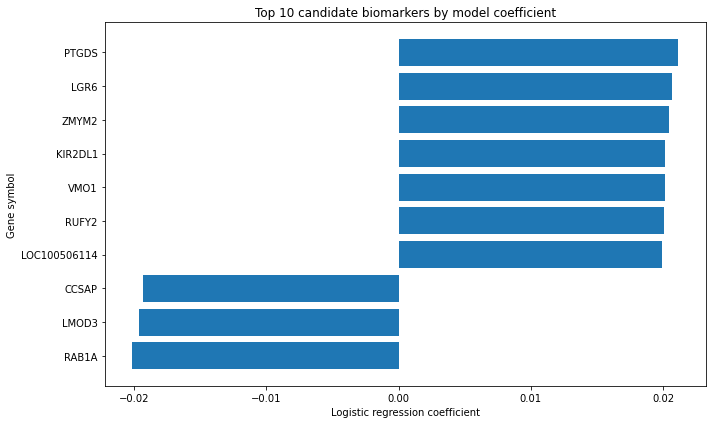

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# финальная таблица для графика
plot_df = top_unique[["gene_symbol", "coefficient", "abs_coef"]].head(10).copy()

# сортируем для красивого horizontal barplot
plot_df = plot_df.sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["gene_symbol"], plot_df["coefficient"])
plt.xlabel("Logistic regression coefficient")
plt.ylabel("Gene symbol")
plt.title("Top 10 candidate biomarkers by model coefficient")
plt.tight_layout()
plt.show()

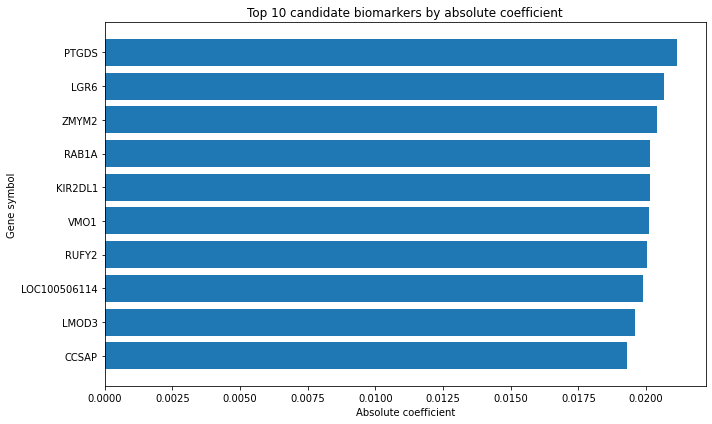

In [19]:
plot_df_abs = top_unique[["gene_symbol", "abs_coef"]].head(10).copy()
plot_df_abs = plot_df_abs.sort_values("abs_coef")

plt.figure(figsize=(10, 6))
plt.barh(plot_df_abs["gene_symbol"], plot_df_abs["abs_coef"])
plt.xlabel("Absolute coefficient")
plt.ylabel("Gene symbol")
plt.title("Top 10 candidate biomarkers by absolute coefficient")
plt.tight_layout()
plt.show()

## Biological Interpretation of Selected Genes

Among the top-ranked model features, **PTGDS** shows the strongest prior support in the Parkinson’s disease literature, including evidence of increased blood expression in PD-discordant twin pairs.

**KIR2DL1** is biologically relevant through its role in natural killer (NK) cell inhibitory signaling, which is consistent with growing evidence for immune system involvement in Parkinson’s disease. However, its support is currently stronger at the level of immune pathways rather than as a validated standalone biomarker.

For **LGR6**, **ZMYM2**, and **RUFY2**, direct evidence linking these genes specifically to Parkinson’s disease appears limited. These genes should therefore be interpreted as exploratory candidates identified by the model.

Overall, this pattern supports the hypothesis that Parkinson’s disease–related transcriptomic signatures in blood are distributed across multiple genes and biological processes, rather than driven by a small number of dominant biomarkers.

## Conclusion

In this project, we investigated whether blood transcriptomic data can be used to distinguish patients with idiopathic Parkinson’s disease (PD) from healthy controls.

Using the GEO dataset GSE99039, we constructed a binary classification pipeline and evaluated multiple machine learning models.

The main findings are:

* Blood gene expression data contains a reproducible predictive signal (ROC-AUC ≈ 0.71)
* Linear models (Logistic Regression and SVM) outperform nonlinear approaches such as Random Forest
* Simple univariate feature selection does not improve performance, suggesting that the signal is distributed across many genes
* Model coefficients reveal a set of candidate transcriptomic biomarkers associated with PD

Among the identified genes, **PTGDS** shows prior support in the literature, while other genes such as **KIR2DL1**, **LGR6**, **ZMYM2**, and **RUFY2** represent potentially novel candidates requiring further validation.

Overall, the results indicate that Parkinson’s disease–related transcriptomic signatures in blood are subtle, distributed, and multi-factorial.

### Limitations

* High dimensionality (≈54k features) relative to sample size
* Probe-level data introduces ambiguity in gene mapping
* Lack of external validation dataset

### Future Work

* Apply regularized models (e.g., L1 / Elastic Net) for more robust feature selection
* Perform pathway-level analysis
* Validate findings on independent datasets
* Explore model interpretability methods (e.g., SHAP)

This project demonstrates the challenges and potential of applying machine learning to high-dimensional biomedical data.

## References

1. Gene Expression Omnibus (GEO), accession GSE99039.
   A blood-based gene signature characterizing idiopathic Parkinson’s disease.

2. Soreq, L. et al. (2013). Major shifts in glial regional identity are a transcriptional hallmark of human brain aging. *Cell Reports*.

3. Leavy, O. (2014). Neurodegenerative diseases: Innate immunity in Parkinson disease. *Nature Reviews Immunology*.

4. Singleton, A. B., Farrer, M. J., & Bonifati, V. (2013). The genetics of Parkinson’s disease: progress and therapeutic implications. *The Lancet Neurology*.

5. Twin study evidence for PTGDS differential expression in Parkinson’s disease:
   https://pubmed.ncbi.nlm.nih.gov/36010675/

6. Vivier, E. et al. (2011). Innate or adaptive immunity? The example of natural killer cells. *Science*.

7. UniProt / NCBI Gene database entries for PTGDS, KIR2DL1, LGR6, ZMYM2, and RUFY2.

## Notes

AI tools (including ChatGPT) were used during the development of this project for code assistance, debugging, and conceptual clarification.

The overall design, implementation, and interpretation of results were carried out independently.